In [1]:
import os
import glob
import time
import numpy as np
from glob import glob

import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow.image import ssim
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

from scipy.linalg import sqrtm
import matplotlib.pyplot as plt

# CONFIGURATION

In [2]:
def set_seed(seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

class CFG:
    BATCH_SIZE = 1       
    BUFFER_SIZE = 200
    LAMBDA = 10
    LR = 0.0002
    SEED = 7

set_seed(CFG.SEED)

# GPU SETUP

In [3]:
try:
    tf.keras.mixed_precision.set_global_policy("float32")
    USE_MIXED = True
    print("Mixed precision enabled")
except Exception:
    USE_MIXED = False
    print("Mixed precision NOT enabled")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
        except Exception:
            pass

Mixed precision enabled


# LOAD DATASET, PREPROCESS IMAGES & BUILD TF DATASET

In [4]:
day_dir = r"C:\MATTHEW\DATA SEKUNDER\Resized 256 x 256\Day"
night_dir = r"C:\MATTHEW\DATA SEKUNDER\Resized 256 x 256\Night"

def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (256, 256))
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0
    return img

def make_dataset(path):
    files = glob(path + "/*.jpg")
    ds = tf.data.Dataset.from_tensor_slices(files)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(CFG.BUFFER_SIZE).repeat()
    ds = ds.batch(CFG.BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

Day = make_dataset(day_dir)
Night = make_dataset(night_dir)

Train = tf.data.Dataset.zip((Day, Night))

# IMAGE POOL

In [5]:
class ImagePool:
    def __init__(self, pool_size=50):
        self.pool_size = pool_size
        self.images = []

    def query(self, image):
        if self.pool_size == 0:
            return image

        if len(self.images) < self.pool_size:
            self.images.append(image)
            return image
        else:
            if random.random() > 0.5:
                idx = random.randint(0, self.pool_size - 1)
                old = self.images[idx]
                self.images[idx] = image
                return old
            else:
                return image

# RESIDUAL BLOCK

In [6]:
initializer = tf.random_normal_initializer(0., 0.02)

def resblock(x, filters):
    y = tf.keras.layers.Conv2D(filters, 3, padding="same",kernel_initializer=initializer,use_bias=False)(x)
    y = tfa.layers.InstanceNormalization()(y)
    y = tf.keras.layers.ReLU()(y)
    y = tf.keras.layers.Conv2D(filters, 3, padding="same",kernel_initializer=initializer,use_bias=False)(y)
    y = tfa.layers.InstanceNormalization()(y)
    return tf.keras.layers.Add()([x, y])

# BUILD GENERATOR

In [7]:
def build_generator():
    inputs = tf.keras.Input((256, 256, 3))

    x1 = tf.keras.layers.Conv2D(32, 7, padding="same",kernel_initializer=initializer, use_bias=False)(inputs)
    x1 = tfa.layers.InstanceNormalization()(x1)
    x1 = tf.keras.layers.ReLU()(x1)

    x2 = tf.keras.layers.Conv2D(64, 3, strides=2, padding="same", kernel_initializer=initializer,use_bias=False)(x1)
    x2 = tfa.layers.InstanceNormalization()(x2)
    x2 = tf.keras.layers.ReLU()(x2)

    x3 = tf.keras.layers.Conv2D(128, 3, strides=2, padding="same",kernel_initializer=initializer,use_bias=False)(x2)
    x3 = tfa.layers.InstanceNormalization()(x3)
    x3 = tf.keras.layers.ReLU()(x3)

    b = resblock(x3, 128)
    b = resblock(b, 128)

    u1 = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding="same",kernel_initializer=initializer,use_bias=False)(b)
    u1 = tfa.layers.InstanceNormalization()(u1)
    u1 = tf.keras.layers.ReLU()(u1)
    u1 = tf.keras.layers.Concatenate()([u1, x2])

    u2 = tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding="same",kernel_initializer=initializer,use_bias=False)(u1)
    u2 = tfa.layers.InstanceNormalization()(u2)
    u2 = tf.keras.layers.ReLU()(u2)
    u2 = tf.keras.layers.Concatenate()([u2, x1])

    out = tf.keras.layers.Conv2D(3, 7, padding="same",activation="tanh",kernel_initializer=initializer)(u2)

    return tf.keras.Model(inputs, out)

# BUILD DISCRIMINATOR

In [8]:
def build_discriminator():
    inp = tf.keras.Input((256, 256, 3))

    x = tf.keras.layers.Conv2D(64, 4, strides=2, padding="same",kernel_initializer=initializer)(inp)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(128, 4, strides=2, padding="same",kernel_initializer=initializer)(x)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(128, 4, strides=2, padding="same",kernel_initializer=initializer)(x)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(128, 4, strides=1, padding="same",kernel_initializer=initializer)(x)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    out = tf.keras.layers.Conv2D(1, 4, strides=1, padding="same",kernel_initializer=initializer)(x)

    return tf.keras.Model(inp, out)

# MODEL SUMMARY GENERATOR

In [9]:
generator = build_generator()
generator.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 32  4704        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 instance_normalization (Instan  (None, 256, 256, 32  64         ['conv2d[0][0]']                 
 ceNormalization)               )                                                             

# LAYER GENERATOR

In [10]:
for i, layer in enumerate(generator.layers):
    print(
        f"{i:03d} | {layer.name:30s} "
        f"| shape : {layer.output_shape} "
        f"| params : {layer.count_params()}"
    )

000 | input_1                        | shape : [(None, 256, 256, 3)] | params : 0
001 | conv2d                         | shape : (None, 256, 256, 32) | params : 4704
002 | instance_normalization         | shape : (None, 256, 256, 32) | params : 64
003 | re_lu                          | shape : (None, 256, 256, 32) | params : 0
004 | conv2d_1                       | shape : (None, 128, 128, 64) | params : 18432
005 | instance_normalization_1       | shape : (None, 128, 128, 64) | params : 128
006 | re_lu_1                        | shape : (None, 128, 128, 64) | params : 0
007 | conv2d_2                       | shape : (None, 64, 64, 128) | params : 73728
008 | instance_normalization_2       | shape : (None, 64, 64, 128) | params : 256
009 | re_lu_2                        | shape : (None, 64, 64, 128) | params : 0
010 | conv2d_3                       | shape : (None, 64, 64, 128) | params : 147456
011 | instance_normalization_3       | shape : (None, 64, 64, 128) | params : 256
012 | re_

# MODEL SUMMARY DISCRIMINATOR

In [11]:
discriminator = build_discriminator()
discriminator.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 conv2d_8 (Conv2D)           (None, 128, 128, 64)      3136      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 128, 128, 64)      0         
                                                                 
 conv2d_9 (Conv2D)           (None, 64, 64, 128)       131200    
                                                                 
 instance_normalization_9 (I  (None, 64, 64, 128)      256       
 nstanceNormalization)                                           
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 64, 64, 128)       0         
                                                           

# LAYER DISCRIMINATOR

In [12]:
for i, layer in enumerate(discriminator.layers):
    print(
        f"{i:03d} | {layer.name:30s} "
        f"| shape : {layer.output_shape} "
        f"| params : {layer.count_params()}"
    )

000 | input_2                        | shape : [(None, 256, 256, 3)] | params : 0
001 | conv2d_8                       | shape : (None, 128, 128, 64) | params : 3136
002 | leaky_re_lu                    | shape : (None, 128, 128, 64) | params : 0
003 | conv2d_9                       | shape : (None, 64, 64, 128) | params : 131200
004 | instance_normalization_9       | shape : (None, 64, 64, 128) | params : 256
005 | leaky_re_lu_1                  | shape : (None, 64, 64, 128) | params : 0
006 | conv2d_10                      | shape : (None, 32, 32, 128) | params : 262272
007 | instance_normalization_10      | shape : (None, 32, 32, 128) | params : 256
008 | leaky_re_lu_2                  | shape : (None, 32, 32, 128) | params : 0
009 | conv2d_11                      | shape : (None, 32, 32, 128) | params : 262272
010 | instance_normalization_11      | shape : (None, 32, 32, 128) | params : 256
011 | leaky_re_lu_3                  | shape : (None, 32, 32, 128) | params : 0
012 | conv2d

# LOSS FUNCTIONS

In [13]:
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def disc_loss(real_logits, fake_logits, smooth_real=0.9):
    real_labels = tf.ones_like(real_logits) * smooth_real
    fake_labels = tf.zeros_like(fake_logits)
    return 0.5 * (bce(real_labels, real_logits) + bce(fake_labels, fake_logits))

def gen_loss(fake_logits):
    return bce(tf.ones_like(fake_logits), fake_logits)

def cycle_loss(real, cycled):
    return CFG.LAMBDA * tf.reduce_mean(tf.abs(real - cycled))

def identity_loss(real, same):
    return CFG.LAMBDA * 0.5 * tf.reduce_mean(tf.abs(real - same))

# CYCLE GAN MODEL

In [14]:
class CycleGAN(tf.keras.Model):
    def __init__(self):
        super().__init__()

        # ===============================
        #  Hyperparameters langsung disini
        # ===============================
        self.D_UPDATE_INTERVAL = 3      # update discriminator setiap 3 langkah
        self.CLIP_NORM = 5.0            # gradient clipping

        self.Gd2n = build_generator()
        self.Gn2d = build_generator()
        self.Dn   = build_discriminator()
        self.Dd   = build_discriminator()

        self.fake_n_pool = ImagePool(50)
        self.fake_d_pool = ImagePool(50)

        # counter untuk interval update D
        self.train_step_index = tf.Variable(0)

    def compile(self, opt):
        super().compile()
        self.opt_g = opt
        self.opt_d = opt

    def train_step(self, batch):
        day, night = batch

        with tf.GradientTape(persistent=True) as tape:

            # =========================
            #   GENERATORS FORWARD PASS
            # =========================
            fake_night = self.Gd2n(day)
            fake_day   = self.Gn2d(night)

            cycled_day   = self.Gn2d(fake_night)
            cycled_night = self.Gd2n(fake_day)

            same_day   = self.Gn2d(day)
            same_night = self.Gd2n(night)

            # =========================
            #   IMAGE POOL SAMPLING
            # =========================
            fake_n_for_d = self.fake_n_pool.query(fake_night)
            fake_d_for_d = self.fake_d_pool.query(fake_day)

            # =========================
            #   DISCRIMINATOR FORWARD
            # =========================
            disc_real_n = self.Dn(night)
            disc_fake_n = self.Dn(fake_n_for_d)

            disc_real_d = self.Dd(day)
            disc_fake_d = self.Dd(fake_d_for_d)

            # =========================
            #         LOSSES
            # =========================
            gl_d2n = gen_loss(disc_fake_n)
            gl_n2d = gen_loss(disc_fake_d)

            cyc_A = cycle_loss(day, cycled_day)
            cyc_B = cycle_loss(night, cycled_night)

            idn = identity_loss(day, same_day) + identity_loss(night, same_night)

            total_g = gl_d2n + gl_n2d + cyc_A + cyc_B + idn

            dl_n = disc_loss(disc_real_n, disc_fake_n)
            dl_d = disc_loss(disc_real_d, disc_fake_d)
            total_d = dl_n + dl_d

        # ============================
        #       GRADIENTS
        # ============================
        g_vars = self.Gd2n.trainable_variables + self.Gn2d.trainable_variables
        d_vars = self.Dn.trainable_variables + self.Dd.trainable_variables

        g_grads = tape.gradient(total_g, g_vars)
        d_grads = tape.gradient(total_d, d_vars)

        # Gradient clipping (langsung dari class variable)
        g_grads = tf.clip_by_global_norm(g_grads, self.CLIP_NORM)[0]
        d_grads = tf.clip_by_global_norm(d_grads, self.CLIP_NORM)[0]

        # Apply generator gradients
        self.opt_g.apply_gradients(zip(g_grads, g_vars))

        # ============================
        #   UPDATE DISCRIMINATOR (interval)
        # ============================
        UPDATE_D = tf.equal(self.train_step_index % self.D_UPDATE_INTERVAL, 0)

        def update_d():
            self.opt_d.apply_gradients(zip(d_grads, d_vars))
            return 0

        def skip_d():
            return 0

        tf.cond(UPDATE_D, update_d, skip_d)

        self.train_step_index.assign_add(1)

        # ============================
        #     METRICS
        # ============================
        g_grad_norm = tf.linalg.global_norm(g_grads)
        d_grad_norm = tf.linalg.global_norm(d_grads)

        g_acc = tf.reduce_mean(tf.cast(tf.sigmoid(disc_fake_n) > 0.5, tf.float32))
        d_acc = (
            tf.reduce_mean(tf.cast(tf.sigmoid(disc_real_n) > 0.5, tf.float32)) +
            tf.reduce_mean(tf.cast(tf.sigmoid(disc_fake_n) < 0.5, tf.float32))
        ) / 2

        return {
            "g_loss": total_g,
            "d_loss": total_d,
            "cycle_A": cyc_A,
            "cycle_B": cyc_B,
            "grad_g": g_grad_norm,
            "grad_d": d_grad_norm,
            "g_acc": g_acc,
            "d_acc": d_acc
        }

# CALLBACK HISTORY

In [15]:
class LossHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.g_losses = []
        self.d_losses = []
        self.g_accs  = []
        self.d_accs  = []
        self.cycle_A = []
        self.cycle_B = []
        self.grad_g  = []
        self.grad_d  = []

    def on_epoch_end(self, epoch, logs=None):
        self.g_losses.append(logs["g_loss"])
        self.d_losses.append(logs["d_loss"])
        self.g_accs.append(logs["g_acc"])
        self.d_accs.append(logs["d_acc"])
        self.cycle_A.append(logs["cycle_A"])
        self.cycle_B.append(logs["cycle_B"])
        self.grad_g.append(logs["grad_g"])
        self.grad_d.append(logs["grad_d"])

# TRAINING SETUP

In [16]:
# Initialize model and optimizer
gan = CycleGAN()
optimizer = tf.keras.optimizers.Adam(CFG.LR, beta_1=0.5)
loss_history = LossHistory()

gan.compile(optimizer)

EPOCHS = 30
steps = 300

# Start timer
start_time = time.time()

# Training
gan.fit(Train,epochs=EPOCHS,steps_per_epoch=steps,callbacks=[loss_history])

# End timer
end_time = time.time()
total_seconds = end_time - start_time

# Convert to hours, minutes, seconds
hours = int(total_seconds // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)

print(f"{hours} Hours {minutes} Minutes {seconds} Seconds")

Epoch 1/30
300/300 [==============================] - 310s 950ms/step - g_loss: 6.3635 - d_loss: 1.2887 - cycle_A: 1.7980 - cycle_B: 1.2634 - grad_g: 5.0000 - grad_d: 1.9720 - g_acc: 0.1576 - d_acc: 0.6490
Epoch 2/30
300/300 [==============================] - 285s 950ms/step - g_loss: 5.7236 - d_loss: 1.1917 - cycle_A: 1.5675 - cycle_B: 0.9103 - grad_g: 5.0000 - grad_d: 2.2646 - g_acc: 0.1661 - d_acc: 0.7331
Epoch 3/30
300/300 [==============================] - 285s 950ms/step - g_loss: 5.6729 - d_loss: 1.1798 - cycle_A: 1.5860 - cycle_B: 0.8086 - grad_g: 5.0000 - grad_d: 2.6189 - g_acc: 0.1777 - d_acc: 0.7192
Epoch 4/30
300/300 [==============================] - 285s 949ms/step - g_loss: 5.4082 - d_loss: 1.2117 - cycle_A: 1.4928 - cycle_B: 0.8050 - grad_g: 5.0000 - grad_d: 2.6926 - g_acc: 0.1694 - d_acc: 0.7146
Epoch 5/30
300/300 [==============================] - 285s 950ms/step - g_loss: 5.4238 - d_loss: 1.2499 - cycle_A: 1.5796 - cycle_B: 0.8159 - grad_g: 5.0000 - grad_d: 2.8463 - 

# GENERATOR LOSS

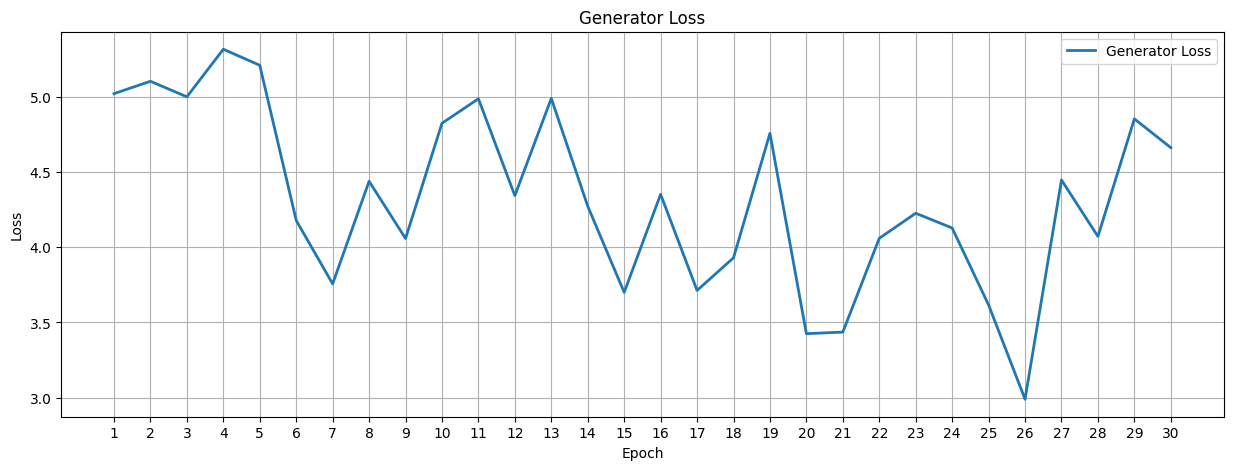

In [45]:
plt.figure(figsize=(15, 5))
epochs = list(range(1, len(loss_history.g_losses) + 1))
plt.plot(epochs, loss_history.g_losses, label="Generator Loss", linewidth=2)
plt.xticks(epochs)  
plt.title("Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# DISCRIMINATOR LOSS

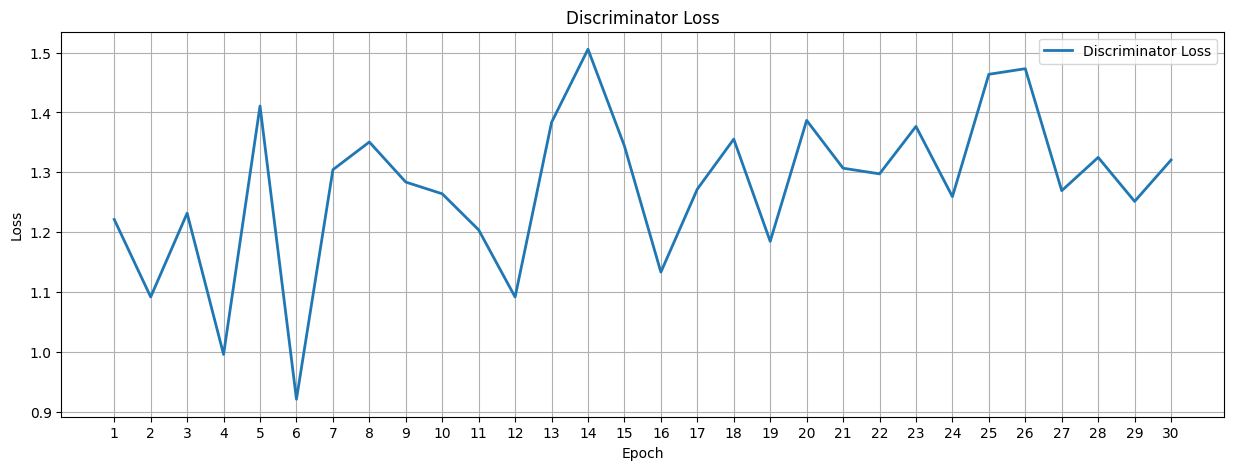

In [36]:
plt.figure(figsize=(15, 5))
epochs = list(range(1, len(loss_history.d_losses) + 1))
plt.plot(epochs, loss_history.d_losses, label="Discriminator Loss", linewidth=2)
plt.xticks(epochs)  
plt.title("Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# GENERATOR & DISCRIMINATOR ACCURACY 

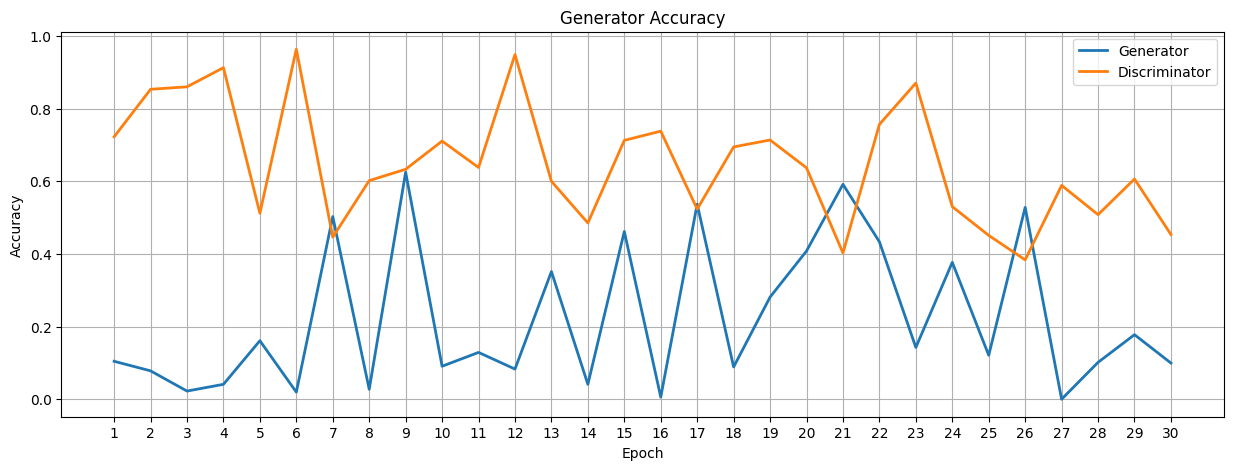

In [43]:
plt.figure(figsize=(15, 5))
epochs = list(range(1, len(loss_history.g_accs) + 1))
plt.plot(epochs, loss_history.g_accs, label="Generator", linewidth=2)
plt.plot(epochs, loss_history.d_accs, label="Discriminator", linewidth=2)
plt.xticks(epochs) 
plt.title("Generator Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# CYCLE CONSISTENCY LOSS

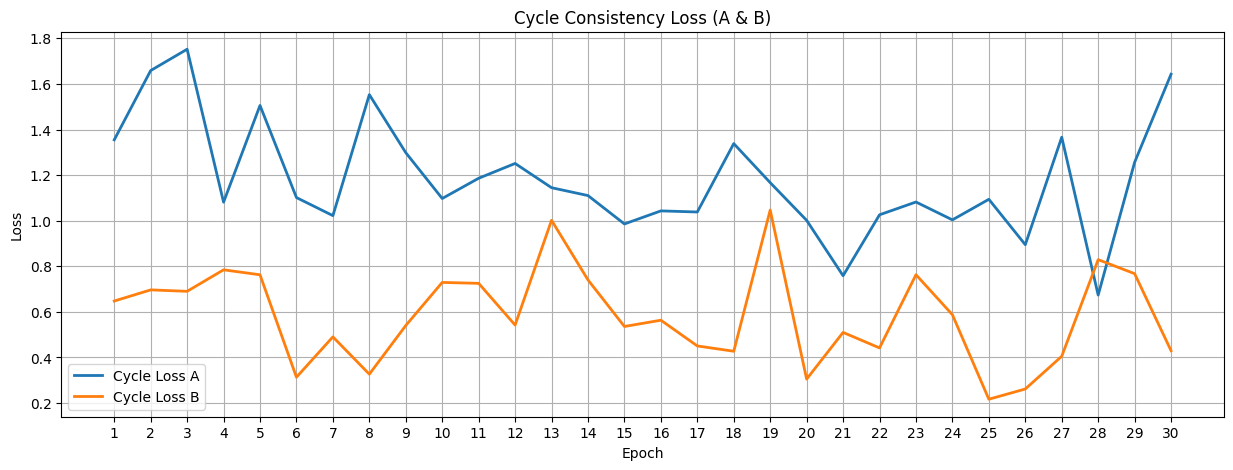

In [39]:
plt.figure(figsize=(15, 5))
epochs = list(range(1, len(loss_history.cycle_A) + 1))
plt.plot(epochs, loss_history.cycle_A, label="Cycle Loss A", linewidth=2)
plt.plot(epochs, loss_history.cycle_B, label="Cycle Loss B", linewidth=2)
plt.xticks(epochs) 
plt.title("Cycle Consistency Loss (A & B)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# GRADIENT NORM MONITORING

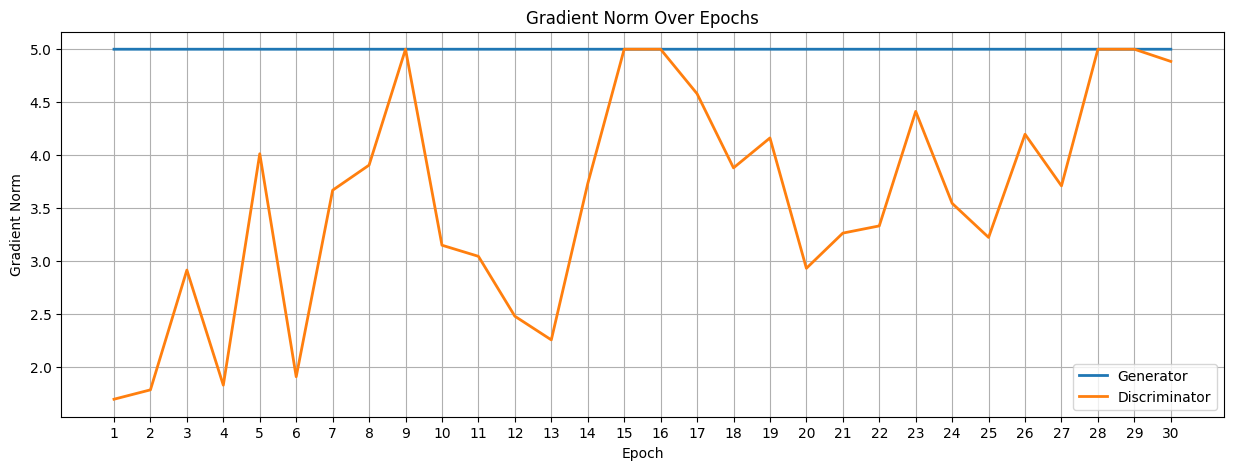

In [41]:
plt.figure(figsize=(15, 5))
epochs = list(range(1, len(loss_history.grad_g) + 1))
plt.plot(epochs, loss_history.grad_g, label="Generator", linewidth=2)
plt.plot(epochs, loss_history.grad_d, label="Discriminator", linewidth=2)
plt.xticks(epochs)  
plt.title("Gradient Norm Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.grid(True)
plt.legend()
plt.show()

# SSIM 

In [23]:
def evaluate_ssim_10_samples(generator, dataset, num_samples=10):
    fig, axes = plt.subplots(2, num_samples, figsize=(3*num_samples, 6))
    fig.subplots_adjust(wspace=0.15, hspace=0.15)

    scores = []

    for i, real_image in enumerate(dataset.take(num_samples)):
        fake_image = generator(real_image, training=False)

        # de-normalize
        real_vis = (real_image[0] + 1) / 2.0
        fake_vis = (fake_image[0] + 1) / 2.0

        # SSIM
        raw_ssim = float(ssim(real_image, fake_image, max_val=2.0).numpy()[0])
        ssim_percent = raw_ssim * 100.0
        scores.append(ssim_percent)

        # Row 1: real
        axes[0, i].imshow(real_vis)
        axes[0, i].set_title("Real", fontsize=12)
        axes[0, i].axis("off")

        # Row 2: fake
        axes[1, i].imshow(fake_vis)
        axes[1, i].set_title(f"SSIM : {ssim_percent:.1f}%", fontsize=12)
        axes[1, i].axis("off")

    plt.show()

    print("Average SSIM :", round(np.mean(scores), 2))
    return scores

# FID

In [24]:
def evaluate_fid_5_samples(generator, dataset, num_samples=5):
    from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
    import numpy as np
    from scipy.linalg import sqrtm

    # Load Inception once
    inception = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))

    # tempat display
    fig, axes = plt.subplots(2, num_samples, figsize=(3*num_samples, 6))
    fig.subplots_adjust(wspace=0.15, hspace=0.15)

    # kumpulan fitur untuk FID global
    real_feats_all = []
    fake_feats_all = []

    def prep(img):
        img = (img + 1.0) * 127.5
        img = tf.image.resize(img, (299, 299))
        img = preprocess_input(img)
        return img

    def get_feat(img):
        img = tf.expand_dims(img, 0)
        feat = inception.predict(img, verbose=0)
        return feat[0]

    for i, real_batch in enumerate(dataset.take(num_samples)):
        real_img = real_batch[0]
        fake_img = generator(tf.expand_dims(real_img, 0), training=False)[0]

        # de-normalize for display
        real_vis = (real_img + 1) / 2.0
        fake_vis = (fake_img + 1) / 2.0

        # convert for inception
        real_prep = prep(real_img)
        fake_prep = prep(fake_img)

        # extract features
        real_feat = get_feat(real_prep)
        fake_feat = get_feat(fake_prep)

        real_feats_all.append(real_feat)
        fake_feats_all.append(fake_feat)

        # "per-image FID-like distance" (bukan FID resmi)
        diff = np.sum((real_feat - fake_feat)**2)

        # --- Display real ---
        axes[0, i].imshow(real_vis)
        axes[0, i].set_title("Real")
        axes[0, i].axis("off")

        # --- Display fake ---
        axes[1, i].imshow(fake_vis)
        axes[1, i].set_title(f"DIST: {diff:.1f}")
        axes[1, i].axis("off")

    plt.show()

    # --------------------
    # Hitung FID GLOBAL
    # --------------------
    real_feats_all = np.array(real_feats_all)
    fake_feats_all = np.array(fake_feats_all)

    mu1, sigma1 = real_feats_all.mean(axis=0), np.cov(real_feats_all, rowvar=False)
    mu2, sigma2 = fake_feats_all.mean(axis=0), np.cov(fake_feats_all, rowvar=False)

    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid_score = np.sum((mu1 - mu2)**2) + np.trace(sigma1 + sigma2 - 2 * covmean)

    print("FID (global, 5 sampel):", fid_score)
    return fid_score

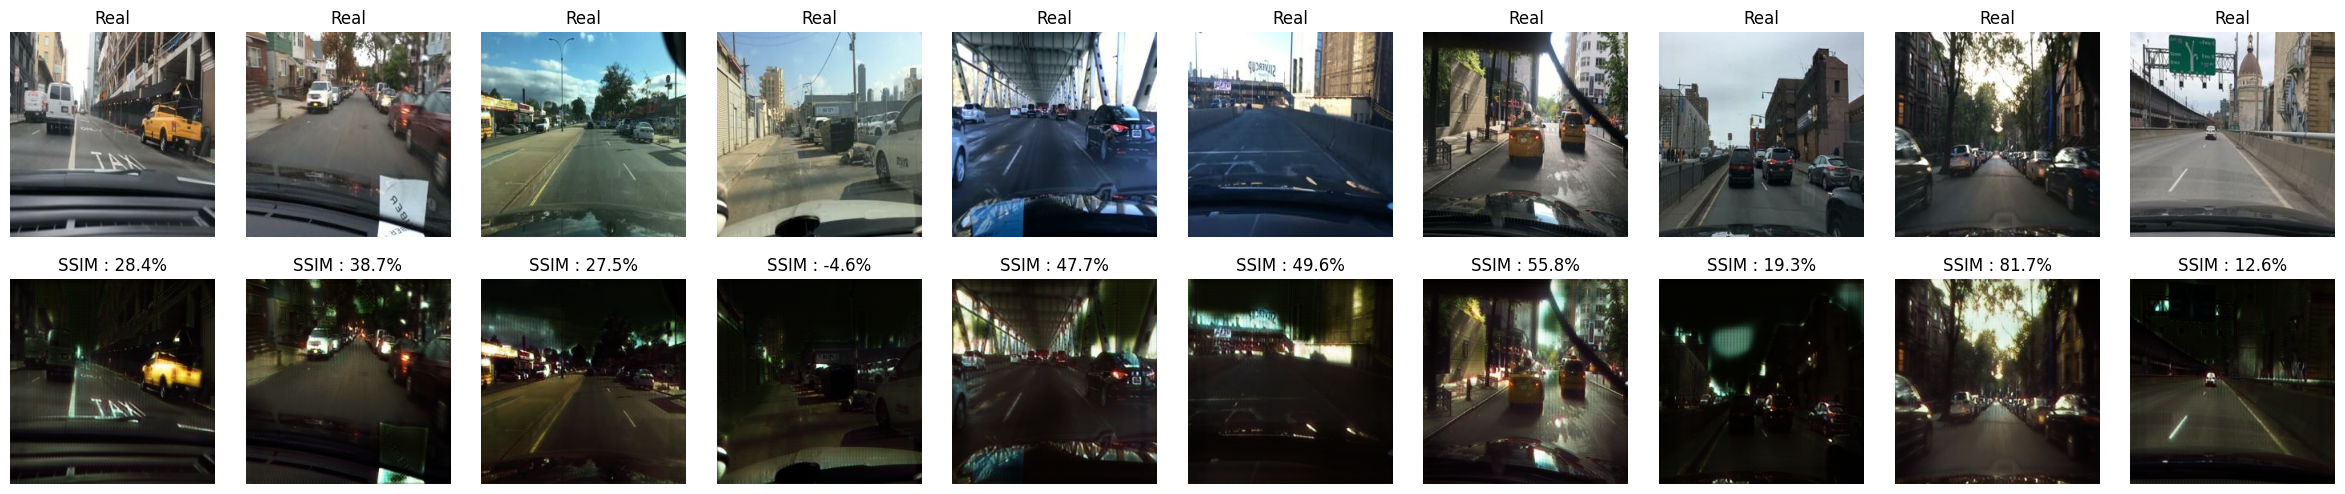

Average SSIM : 35.68


[28.394219279289246,
 38.71599733829498,
 27.523663640022278,
 -4.6019624918699265,
 47.728705406188965,
 49.57641661167145,
 55.78269958496094,
 19.300414621829987,
 81.749826669693,
 12.642310559749603]

In [25]:
evaluate_ssim_10_samples(gan.Gd2n, Day)

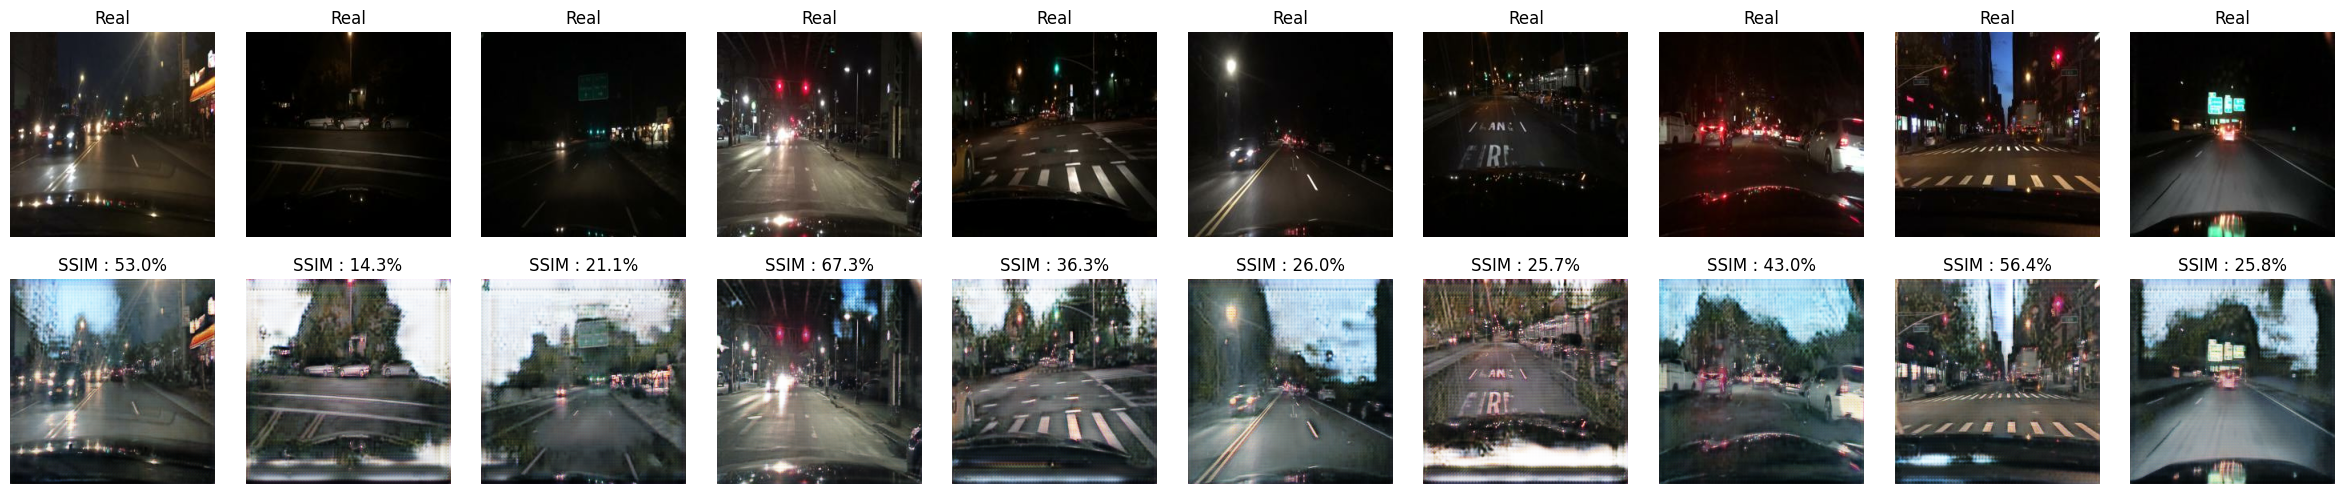

Average SSIM : 36.89


[53.027164936065674,
 14.277525246143341,
 21.119733154773712,
 67.34158396720886,
 36.30768954753876,
 25.976285338401794,
 25.679853558540344,
 42.96288192272186,
 56.41970634460449,
 25.802084803581238]

In [26]:
evaluate_ssim_10_samples(gan.Gn2d, Night)

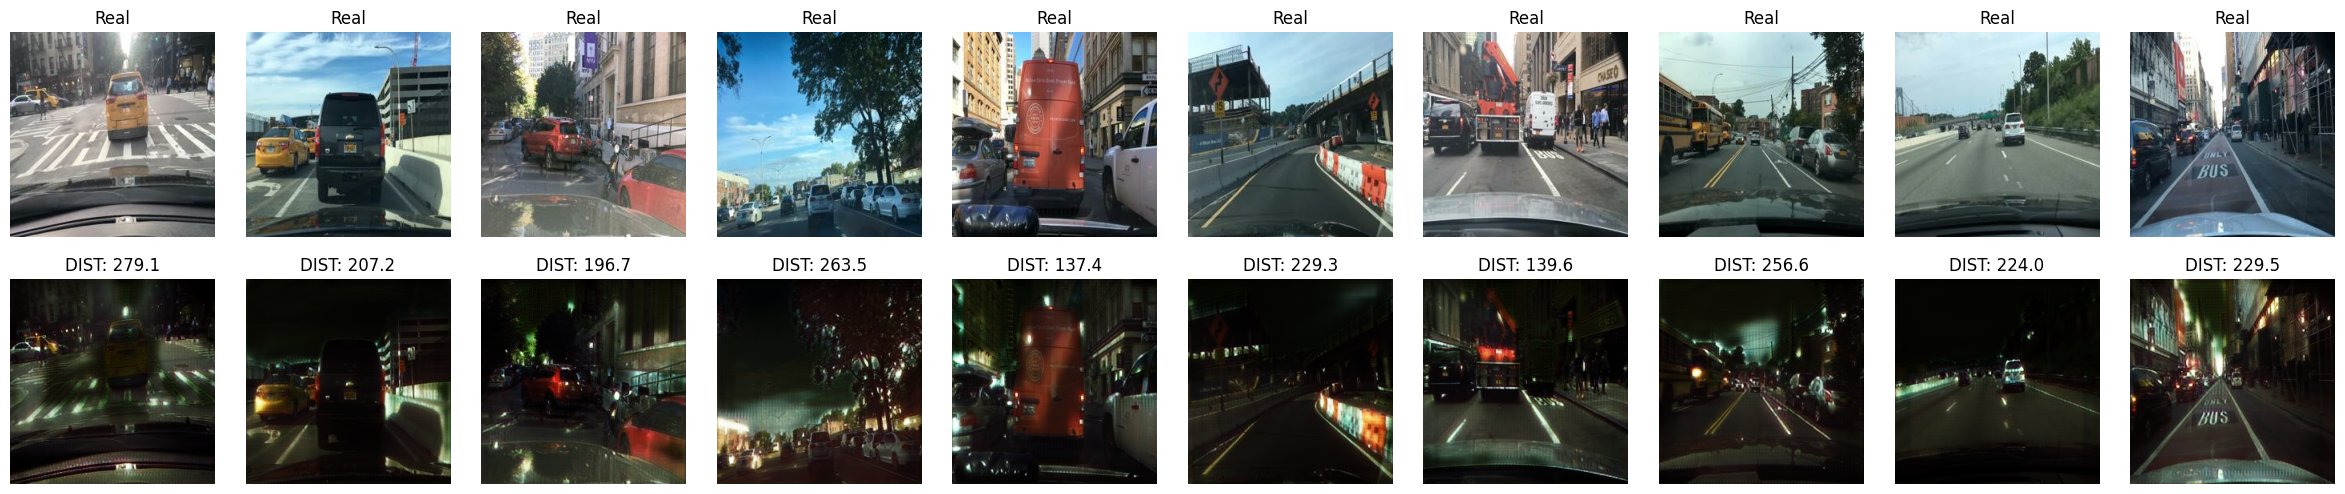

FID (global, 5 sampel): 223.8104744022442


In [27]:
fid_score = evaluate_fid_5_samples(generator=gan.Gd2n,dataset=Day,num_samples=10)

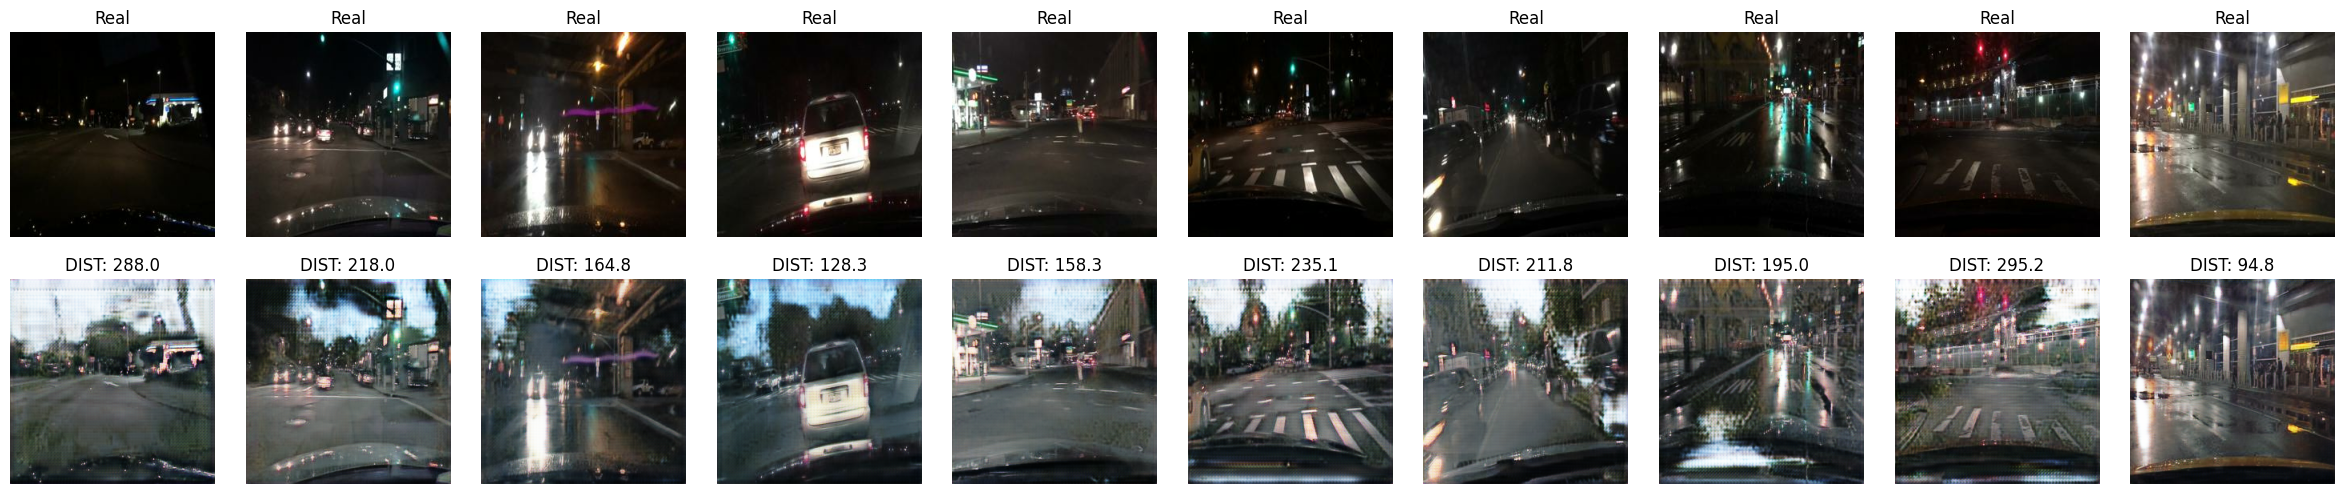

FID (global, 5 sampel): 204.79968898485944


In [28]:
fid_score = evaluate_fid_5_samples(generator=gan.Gn2d,dataset=Night,num_samples=10)